In [2]:
#Import Libraries

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [4]:
#Set Random Seed
#Assignment requires reproducibility

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

In [5]:
#Load Dataset
#Download KMNIST

transform = transforms.ToTensor()

train_dataset = datasets.KMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.KMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100.0%
100.0%
100.0%
100.0%


In [10]:
#Verify Dataset

print(len(train_dataset))
print(len(test_dataset))

60000
10000


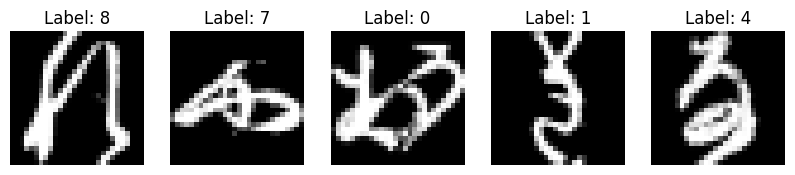

In [11]:
#Display Some KMNIST Images

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(10, 3))

for i in range(5):
    image, label = train_dataset[i]

    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.show()

In [12]:
#Create DataLoaders
#Now we need to create batches so PyTorch can feed data to the neural network efficiently.from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [13]:
print(len(train_loader))
print(len(test_loader))

938
157


In [14]:
#Create the Neural Network

import torch.nn as nn

class KMNISTNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = x.view(-1, 784)
        return self.network(x)

In [15]:
model = KMNISTNet()

print(model)

KMNISTNet(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [16]:
#Create the Loss Function

criterion = nn.CrossEntropyLoss()

In [17]:
#Verify the Model Works
#Before writing training code, let's make sure the network can process one batch without errors

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [18]:
outputs = model(images)

print(outputs.shape)

torch.Size([64, 10])


In [19]:
#Create AdamW Optimizer

import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=0.01
)

In [20]:
#Verify

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.01
)


In [21]:
#Create the Training Function

def train_model(model,
                train_loader,
                optimizer,
                criterion):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [22]:
#Create the Evaluation Function
#Now we need a function for validation/testing

def evaluate_model(model,
                   data_loader,
                   criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in data_loader:

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(data_loader)

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [23]:
#Run One Training Epoch
#Let's verify the whole pipeline works

train_loss, train_acc = train_model(
    model,
    train_loader,
    optimizer,
    criterion
)

print("Train Loss:", train_loss)
print("Train Accuracy:", train_acc)

Train Loss: 0.5151982883146322
Train Accuracy: 84.695


In [24]:
#Evaluate on Test Set
#Now let's verify the evaluation function

test_loss, test_acc = evaluate_model(
    model,
    test_loader,
    criterion
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Test Loss: 0.6219160902272364
Test Accuracy: 80.41


In [25]:
#Create Lists to Store Metrics

train_losses = []
train_accuracies = []

test_losses = []
test_accuracies = []

In [26]:
#Create 20-Epoch Training Loop

EPOCHS = 20

for epoch in range(EPOCHS):

    train_loss, train_acc = train_model(
        model,
        train_loader,
        optimizer,
        criterion
    )

    test_loss, test_acc = evaluate_model(
        model,
        test_loader,
        criterion
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.2f}%"
    )

Epoch 1/20 | Train Loss: 0.2527 | Train Acc: 92.50% | Test Loss: 0.5313 | Test Acc: 83.68%
Epoch 2/20 | Train Loss: 0.1769 | Train Acc: 94.73% | Test Loss: 0.4338 | Test Acc: 87.20%
Epoch 3/20 | Train Loss: 0.1341 | Train Acc: 95.99% | Test Loss: 0.4201 | Test Acc: 88.09%
Epoch 4/20 | Train Loss: 0.1039 | Train Acc: 96.88% | Test Loss: 0.4226 | Test Acc: 88.49%
Epoch 5/20 | Train Loss: 0.0834 | Train Acc: 97.48% | Test Loss: 0.4318 | Test Acc: 89.09%
Epoch 6/20 | Train Loss: 0.0669 | Train Acc: 98.04% | Test Loss: 0.4382 | Test Acc: 89.00%
Epoch 7/20 | Train Loss: 0.0546 | Train Acc: 98.32% | Test Loss: 0.4485 | Test Acc: 88.84%
Epoch 8/20 | Train Loss: 0.0453 | Train Acc: 98.64% | Test Loss: 0.4622 | Test Acc: 89.57%
Epoch 9/20 | Train Loss: 0.0366 | Train Acc: 98.86% | Test Loss: 0.5019 | Test Acc: 89.24%
Epoch 10/20 | Train Loss: 0.0329 | Train Acc: 98.94% | Test Loss: 0.5134 | Test Acc: 89.10%
Epoch 11/20 | Train Loss: 0.0265 | Train Acc: 99.17% | Test Loss: 0.5306 | Test Acc: 89.2

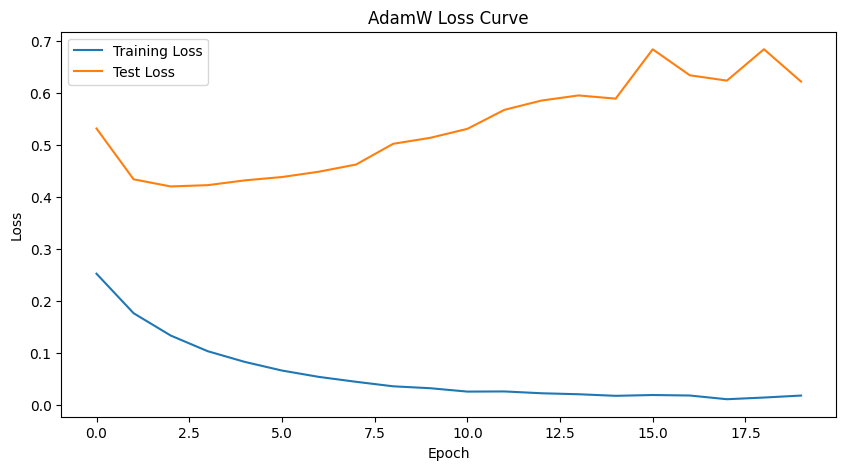

In [27]:
#Create Loss Curve

plt.figure(figsize=(10,5))

plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Test Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('AdamW Loss Curve')

plt.legend()

plt.show()

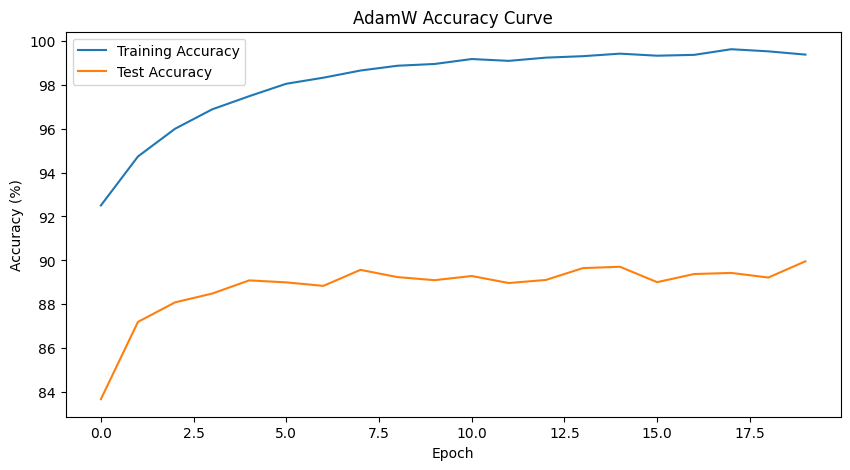

In [28]:
#Create Accuracy Curve

plt.figure(figsize=(10,5))

plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('AdamW Accuracy Curve')

plt.legend()

plt.show()

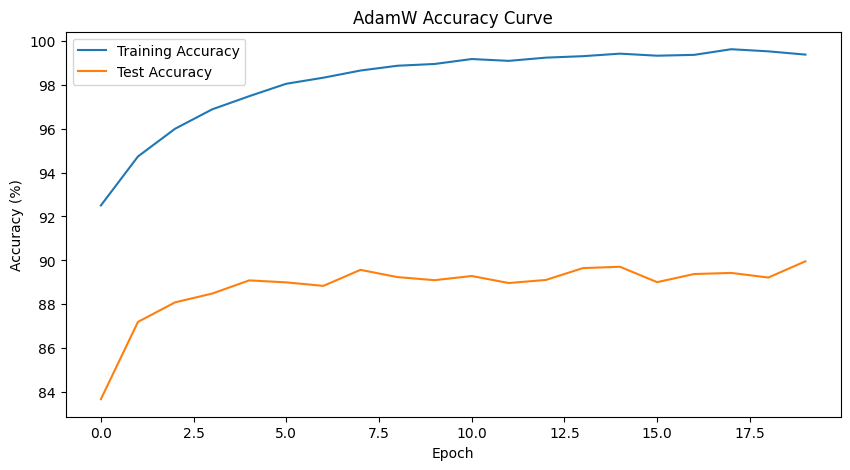

In [29]:
#Save the Accuracy Graph

plt.figure(figsize=(10,5))

plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('AdamW Accuracy Curve')

plt.legend()

plt.savefig("adamw_accuracy_curve.png")

plt.show()

In [30]:
#Verify File Exists

import os

print(os.listdir())

['.anaconda', '.conda', '.continuum', '.copilot', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.matplotlib', '.python_history', '.virtual_documents', '.vscode', '.vscode-shared', 'adamw_accuracy_curve.png', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'data', 'Dilkhush_Yadav.ipynb', 'Dilkhush_Yadav_5501_Lab01.ipynb', 'Dilkhush_Yadav_Lab03.ipynb', 'Dilkhush_Yadav_Lab04.ipynb', 'Dilkhush_Yadav_Lab2.ipynb', 'Dilkhush_Yadav_LAB4.ipynb', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'Music', 'My Documents', 'N01723579_Q1.ipynb', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{3ec3928d-4f18-11f1-95b8-30894aed2523}.TxR.0.regtrans-ms', 'NTUSER.DAT{3ec3928d-4f18-11f1-95b8-30894aed2523}.TxR.1.regtrans-ms', 'NTUSER.DAT{3ec3928d-4f18-11f1-95b8-30894aed2523}.TxR.2.regtrans-ms', 'NTUSER.DAT{3ec3928d-4f18-11f1-95b8-30894aed2523}.TxR.blf', 'NTUSER.DAT{3ec3928e-4f18-11f1-95b8-30894aed2523

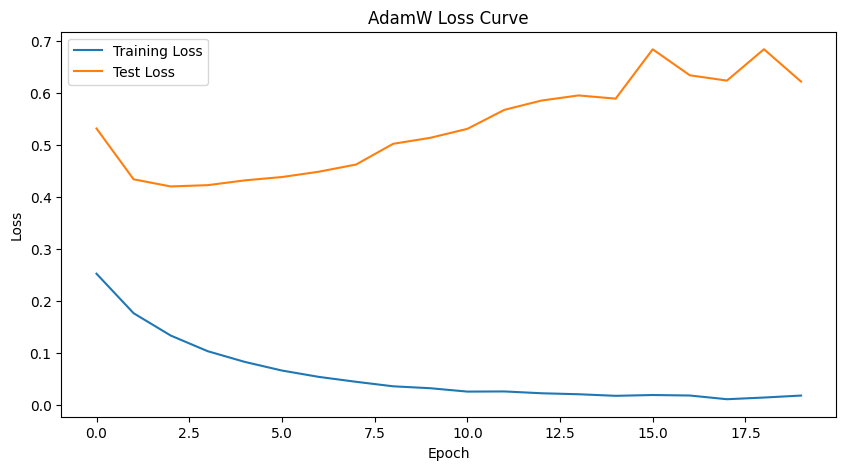

In [31]:
#Save the Loss Curve

plt.figure(figsize=(10,5))

plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Test Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('AdamW Loss Curve')

plt.legend()

plt.savefig("adamw_loss_curve.png")

plt.show()

In [32]:
#Verify Both Files Exist

print(os.listdir())

['.anaconda', '.conda', '.continuum', '.copilot', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.matplotlib', '.python_history', '.virtual_documents', '.vscode', '.vscode-shared', 'adamw_accuracy_curve.png', 'adamw_loss_curve.png', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'data', 'Dilkhush_Yadav.ipynb', 'Dilkhush_Yadav_5501_Lab01.ipynb', 'Dilkhush_Yadav_Lab03.ipynb', 'Dilkhush_Yadav_Lab04.ipynb', 'Dilkhush_Yadav_Lab2.ipynb', 'Dilkhush_Yadav_LAB4.ipynb', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'Music', 'My Documents', 'N01723579_Q1.ipynb', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{3ec3928d-4f18-11f1-95b8-30894aed2523}.TxR.0.regtrans-ms', 'NTUSER.DAT{3ec3928d-4f18-11f1-95b8-30894aed2523}.TxR.1.regtrans-ms', 'NTUSER.DAT{3ec3928d-4f18-11f1-95b8-30894aed2523}.TxR.2.regtrans-ms', 'NTUSER.DAT{3ec3928d-4f18-11f1-95b8-30894aed2523}.TxR.blf', 'NTUSER.DAT{3ec3928e-4f1

In [33]:
#Create a Results Summary Table

results = {
    "Optimizer": "AdamW",
    "Final Train Accuracy": train_accuracies[-1],
    "Final Test Accuracy": test_accuracies[-1],
    "Final Train Loss": train_losses[-1],
    "Final Test Loss": test_losses[-1],
    "Best Test Accuracy": max(test_accuracies)
}

results_df = pd.DataFrame([results])

results_df

,Optimizer,Final Train Accuracy,Final Test Accuracy,Final Train Loss,Final Test Loss,Best Test Accuracy
0,AdamW,99.37,89.96,0.018846,0.621338,89.96


In [34]:
#Import KFold

from sklearn.model_selection import KFold

In [35]:
#Create AdamW Configurations

configs = [
    {"lr": 0.1, "weight_decay": 0.001},
    {"lr": 0.01, "weight_decay": 0.01},
    {"lr": 0.001, "weight_decay": 0.01},
    {"lr": 0.0001, "weight_decay": 0.1}
]

print(configs)

[{'lr': 0.1, 'weight_decay': 0.001}, {'lr': 0.01, 'weight_decay': 0.01}, {'lr': 0.001, 'weight_decay': 0.01}, {'lr': 0.0001, 'weight_decay': 0.1}]


In [36]:
#Create the 5-Fold Cross Validation Object

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

print(kfold)

KFold(n_splits=5, random_state=42, shuffle=True)


In [37]:
#Create Results Storage

cv_results = []

In [38]:
#Test That KFold Is Working

for fold, (train_idx, val_idx) in enumerate(kfold.split(train_dataset)):

    print(
        f"Fold {fold+1}: "
        f"Train Samples = {len(train_idx)}, "
        f"Validation Samples = {len(val_idx)}"
    )

Fold 1: Train Samples = 48000, Validation Samples = 12000
Fold 2: Train Samples = 48000, Validation Samples = 12000
Fold 3: Train Samples = 48000, Validation Samples = 12000
Fold 4: Train Samples = 48000, Validation Samples = 12000
Fold 5: Train Samples = 48000, Validation Samples = 12000


In [39]:
#Create Fold DataLoaders

from torch.utils.data import Subset

In [40]:
#Test One Fold

for fold, (train_idx, val_idx) in enumerate(kfold.split(train_dataset)):

    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(train_dataset, val_idx)

    train_loader_cv = DataLoader(
        train_subset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader_cv = DataLoader(
        val_subset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    print(f"Fold {fold+1}")
    print("Train batches:", len(train_loader_cv))
    print("Validation batches:", len(val_loader_cv))

    break

Fold 1
Train batches: 750
Validation batches: 188


In [41]:
#Create Storage for Fold Accuracies

fold_accuracies = []

In [42]:
#Run 5-Fold Cross Validation for ONE Configuration

for fold, (train_idx, val_idx) in enumerate(kfold.split(train_dataset)):

    print(f"\nFold {fold+1}")

    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(train_dataset, val_idx)

    train_loader_cv = DataLoader(
        train_subset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader_cv = DataLoader(
        val_subset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model = KMNISTNet()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=0.001,
        weight_decay=0.01
    )

    for epoch in range(5):
        train_model(
            model,
            train_loader_cv,
            optimizer,
            criterion
        )

    val_loss, val_acc = evaluate_model(
        model,
        val_loader_cv,
        criterion
    )

    fold_accuracies.append(val_acc)

    print(f"Validation Accuracy: {val_acc:.2f}%")


Fold 1
Validation Accuracy: 94.25%

Fold 2
Validation Accuracy: 94.43%

Fold 3
Validation Accuracy: 94.78%

Fold 4
Validation Accuracy: 94.41%

Fold 5
Validation Accuracy: 94.72%


In [43]:
#Calculate Mean and Standard Deviation

import numpy as np

mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

print("Fold Accuracies:", fold_accuracies)
print(f"Mean Accuracy: {mean_accuracy:.2f}%")
print(f"Standard Deviation: {std_accuracy:.2f}")

Fold Accuracies: [94.25, 94.43333333333334, 94.78333333333333, 94.40833333333333, 94.725]
Mean Accuracy: 94.52%
Standard Deviation: 0.20


In [44]:
cv_results = []

cv_results.append({
    "lr": 0.001,
    "weight_decay": 0.01,
    "mean_accuracy": mean_accuracy,
    "std_accuracy": std_accuracy
})

In [45]:
fold_accuracies = []

In [46]:
#Configuration 2 - Setup 5-Fold Cross Validation

for fold, (train_idx, val_idx) in enumerate(kfold.split(train_dataset)):

    print(f"\nFold {fold+1}")

    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(train_dataset, val_idx)

    train_loader_cv = DataLoader(
        train_subset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader_cv = DataLoader(
        val_subset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model = KMNISTNet()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=0.01,
        weight_decay=0.01
    )


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


In [49]:
#Train Model Across 5 Folds

for epoch in range(5):

    train_model(
        model,
        train_loader_cv,
        optimizer,
        criterion
    )

_, val_acc = evaluate_model(
    model,
    val_loader_cv,
    criterion
)

fold_accuracies.append(val_acc)

print(f"Validation Accuracy: {val_acc:.2f}%")

Validation Accuracy: 93.15%


In [50]:
print(fold_accuracies)
print(len(fold_accuracies))

[93.15]
1


In [51]:
for fold, (train_idx, val_idx) in enumerate(kfold.split(train_dataset)):
    print(f"Fold {fold+1}")

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


In [52]:
#Run All 5 Folds

fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(train_dataset)):

    print(f"\nFold {fold+1}")

    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(train_dataset, val_idx)

    train_loader_cv = DataLoader(
        train_subset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader_cv = DataLoader(
        val_subset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model = KMNISTNet()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=0.01,
        weight_decay=0.01
    )

    for epoch in range(5):

        train_model(
            model,
            train_loader_cv,
            optimizer,
            criterion
        )

    _, val_acc = evaluate_model(
        model,
        val_loader_cv,
        criterion
    )

    fold_accuracies.append(val_acc)

    print(f"Validation Accuracy: {val_acc:.2f}%")


Fold 1
Validation Accuracy: 92.79%

Fold 2
Validation Accuracy: 92.11%

Fold 3
Validation Accuracy: 93.18%

Fold 4
Validation Accuracy: 93.04%

Fold 5
Validation Accuracy: 93.02%


In [53]:
#Calculate Mean and Standard Deviation

mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

print(f"Mean Accuracy: {mean_accuracy:.2f}%")
print(f"Standard Deviation: {std_accuracy:.2f}")

Mean Accuracy: 92.83%
Standard Deviation: 0.38


In [55]:
#Save Configuration 2 Results

cv_results.append({
    "lr": 0.01,
    "weight_decay": 0.01,
    "mean_accuracy": mean_accuracy,
    "std_accuracy": std_accuracy
})

In [56]:
#Configuration 3 - Reset Fold Accuracies

fold_accuracies = []

In [57]:
#Configuration 3 - Run All 5 Folds

fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(train_dataset)):

    print(f"\nFold {fold+1}")

    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(train_dataset, val_idx)

    train_loader_cv = DataLoader(
        train_subset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader_cv = DataLoader(
        val_subset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model = KMNISTNet()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=0.1,
        weight_decay=0.001
    )

    for epoch in range(5):

        train_model(
            model,
            train_loader_cv,
            optimizer,
            criterion
        )

    _, val_acc = evaluate_model(
        model,
        val_loader_cv,
        criterion
    )

    fold_accuracies.append(val_acc)

    print(f"Validation Accuracy: {val_acc:.2f}%")


Fold 1
Validation Accuracy: 18.95%

Fold 2
Validation Accuracy: 12.78%

Fold 3
Validation Accuracy: 9.95%

Fold 4
Validation Accuracy: 15.18%

Fold 5
Validation Accuracy: 17.05%


In [58]:
#Configuration 3 - Calculate Mean and Standard Deviation

mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

print(f"Mean Accuracy: {mean_accuracy:.2f}%")
print(f"Standard Deviation: {std_accuracy:.2f}")

Mean Accuracy: 14.78%
Standard Deviation: 3.16


In [59]:
#Save Configuration 3 Results

cv_results.append({
    "lr": 0.1,
    "weight_decay": 0.001,
    "mean_accuracy": mean_accuracy,
    "std_accuracy": std_accuracy
})

In [60]:
#Configuration 4 - Reset Fold Accuracies

fold_accuracies = []

In [61]:
#Configuration 4 - Run All 5 Folds

fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(train_dataset)):

    print(f"\nFold {fold+1}")

    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(train_dataset, val_idx)

    train_loader_cv = DataLoader(
        train_subset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader_cv = DataLoader(
        val_subset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model = KMNISTNet()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=0.0001,
        weight_decay=0.1
    )

    for epoch in range(5):

        train_model(
            model,
            train_loader_cv,
            optimizer,
            criterion
        )

    _, val_acc = evaluate_model(
        model,
        val_loader_cv,
        criterion
    )

    fold_accuracies.append(val_acc)

    print(f"Validation Accuracy: {val_acc:.2f}%")


Fold 1
Validation Accuracy: 87.65%

Fold 2
Validation Accuracy: 86.98%

Fold 3
Validation Accuracy: 87.40%

Fold 4
Validation Accuracy: 87.52%

Fold 5
Validation Accuracy: 88.14%


In [62]:
#Configuration 4 - Calculate Mean and Standard Deviation

mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

print(f"Mean Accuracy: {mean_accuracy:.2f}%")
print(f"Standard Deviation: {std_accuracy:.2f}")

Mean Accuracy: 87.54%
Standard Deviation: 0.38


In [63]:
#Save Configuration 4 Results

cv_results.append({
    "lr": 0.0001,
    "weight_decay": 0.1,
    "mean_accuracy": mean_accuracy,
    "std_accuracy": std_accuracy
})

In [64]:
#Create AdamW Comparison Table

results_df = pd.DataFrame(cv_results)

results_df

,lr,weight_decay,mean_accuracy,std_accuracy
0,0.0010,0.010,94.520000,0.202114
1,0.0100,0.010,92.828333,0.381248
2,0.1000,0.001,14.781667,3.162701
3,0.0001,0.100,87.538333,0.375263


In [65]:
#Find Best AdamW Configuration

best_config = results_df.loc[
    results_df["mean_accuracy"].idxmax()
]

best_config

lr                0.001000
weight_decay      0.010000
mean_accuracy    94.520000
std_accuracy      0.202114
Name: 0, dtype: float64

In [66]:
#Create Final AdamW Model

model = KMNISTNet()

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=0.01
)

In [67]:
#Create Storage for Final 20-Epoch Training

train_losses = []
train_accuracies = []

test_losses = []
test_accuracies = []

In [68]:
#Final AdamW Training Loop (20 Epochs)

EPOCHS = 20

for epoch in range(EPOCHS):

    train_loss, train_acc = train_model(
        model,
        train_loader,
        optimizer,
        criterion
    )

    test_loss, test_acc = evaluate_model(
        model,
        test_loader,
        criterion
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.2f}%"
    )

Epoch 1/20 | Train Loss: 0.5139 | Train Acc: 84.75% | Test Loss: 0.6188 | Test Acc: 81.00%
Epoch 2/20 | Train Loss: 0.2457 | Train Acc: 92.73% | Test Loss: 0.4797 | Test Acc: 86.00%
Epoch 3/20 | Train Loss: 0.1725 | Train Acc: 94.87% | Test Loss: 0.4453 | Test Acc: 86.97%
Epoch 4/20 | Train Loss: 0.1296 | Train Acc: 96.18% | Test Loss: 0.4128 | Test Acc: 87.93%
Epoch 5/20 | Train Loss: 0.1014 | Train Acc: 96.97% | Test Loss: 0.4348 | Test Acc: 88.34%
Epoch 6/20 | Train Loss: 0.0795 | Train Acc: 97.65% | Test Loss: 0.4028 | Test Acc: 89.11%
Epoch 7/20 | Train Loss: 0.0636 | Train Acc: 98.12% | Test Loss: 0.4342 | Test Acc: 89.07%
Epoch 8/20 | Train Loss: 0.0520 | Train Acc: 98.43% | Test Loss: 0.4418 | Test Acc: 89.28%
Epoch 9/20 | Train Loss: 0.0414 | Train Acc: 98.74% | Test Loss: 0.5470 | Test Acc: 87.68%
Epoch 10/20 | Train Loss: 0.0358 | Train Acc: 98.89% | Test Loss: 0.5192 | Test Acc: 88.83%
Epoch 11/20 | Train Loss: 0.0287 | Train Acc: 99.13% | Test Loss: 0.5625 | Test Acc: 88.1

In [69]:
#Final AdamW Summary Table

final_results = {
    "Optimizer": "AdamW",
    "Best Learning Rate": 0.001,
    "Best Weight Decay": 0.01,
    "Mean CV Accuracy": 94.52,
    "CV Std": 0.20,
    "Final Train Accuracy": train_accuracies[-1],
    "Final Test Accuracy": test_accuracies[-1],
    "Best Test Accuracy": max(test_accuracies),
    "Final Train Loss": train_losses[-1],
    "Final Test Loss": test_losses[-1]
}

pd.DataFrame([final_results])

,Optimizer,Best Learning Rate,Best Weight Decay,Mean CV Accuracy,CV Std,Final Train Accuracy,Final Test Accuracy,Best Test Accuracy,Final Train Loss,Final Test Loss
0,AdamW,0.001,0.01,94.52,0.2,99.416667,89.85,89.9,0.016846,0.654623


# Final AdamW Results

## Hyperparameter Tuning (5-Fold Cross Validation)

Four AdamW configurations were evaluated:

| Learning Rate | Weight Decay | Mean CV Accuracy (%) | Std Dev |
|--------------|-------------|---------------------|---------|
| 0.001 | 0.01 | 94.52 | 0.20 |
| 0.01 | 0.01 | 92.83 | 0.38 |
| 0.1 | 0.001 | 14.78 | 3.16 |
| 0.0001 | 0.1 | 87.54 | 0.38 |

### Best Configuration
- Learning Rate: **0.001**
- Weight Decay: **0.01**
- Mean Cross-Validation Accuracy: **94.52%**

## Final Model Performance

The model was retrained on the full training dataset using the best AdamW configuration and evaluated on the test set.

| Metric | Value |
|----------|----------|
| Final Train Accuracy | 99.42% |
| Final Test Accuracy | 89.85% |
| Best Test Accuracy | 89.90% |
| Final Train Loss | 0.0168 |
| Final Test Loss | 0.6546 |

## Conclusion

AdamW achieved its best performance with a learning rate of **0.001** and weight decay of **0.01**. The model reached a final test accuracy of **89.85%** and a best test accuracy of **89.90%**, demonstrating strong performance on the KMNIST dataset.